## 1. Import Necessary Libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

## 2. Data Collection

In [4]:
college_data = pd.read_csv("college_list.csv")
college_data.head()

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9


## 3. Data Understanding

In [5]:
college_data.shape

(500, 6)

In [6]:
college_data.isna().sum()

College_Name             0
Student_Faculty_Ratio    0
Annual_Fees_INR          0
Placement_Percentage     0
Average_Package_LPA      0
Infrastructure_Score     0
dtype: int64

In [7]:
college_data.describe()

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
count,500.000000,500.000000,500.000000,500.000000,500.00000
mean,18.084000,138763.710000,69.000000,6.991720,5.97600
std,6.683283,63928.678815,17.193465,2.917991,2.00486
min,8.000000,30404.000000,40.000000,2.000000,3.00000
25%,12.000000,82610.500000,53.750000,4.472500,4.00000
50%,18.000000,140290.500000,69.000000,7.155000,6.00000
75%,24.000000,193422.000000,84.000000,9.432500,8.00000
max,29.000000,249930.000000,99.000000,11.990000,9.00000


## 4. Data Preparation

### 4.1 Delete Unnecessary Features

In [8]:
X = college_data.drop("College_Name", axis=1)
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
...,...,...,...,...,...
495,17,106323,56,9.33,5
496,12,39111,76,3.62,7
497,16,199182,64,3.88,3
498,10,46389,77,9.31,6


## 4.2 Applying Data Transformation Techniques

In [9]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled)
X_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [10]:
X_scaled.mean().round(4),X_scaled.std().round(4)

(0    0.0
 1    0.0
 2   -0.0
 3    0.0
 4   -0.0
 dtype: float64,
 0    1.001
 1    1.001
 2    1.001
 3    1.001
 4    1.001
 dtype: float64)

## 5. Model Building - Build Cluster algorithm

In [11]:
clusters_new = KMeans(n_clusters=3, random_state=12)
clusters_new.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [12]:
clusters_new.labels_

array([2, 0, 0, 0, 2, 1, 1, 0, 2, 1, 1, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 2,
       2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 1, 2, 2, 1, 1, 0, 2, 1, 1, 1, 1, 0,
       1, 0, 2, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 1, 0, 2, 0,
       1, 1, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 1, 2,
       2, 2, 2, 1, 1, 0, 0, 1, 1, 2, 1, 2, 2, 1, 2, 2, 2, 2, 0, 1, 2, 2,
       0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 1, 2, 2, 2, 0, 2, 2, 1, 0, 0, 0,
       0, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 1, 0, 0, 2, 2, 0, 0, 2, 0, 0,
       0, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 2, 2, 2, 1, 2, 0, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2, 0, 2,
       2, 2, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 2, 0, 1,
       1, 1, 1, 0, 1, 2, 2, 1, 0, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 0, 2, 2,
       0, 0, 2, 2, 1, 2, 2, 0, 1, 0, 1, 1, 0, 2, 0, 1, 1, 1, 2, 2, 0, 1,
       1, 0, 2, 1, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 1, 0, 1, 1, 1, 2, 2,
       1, 2, 0, 0, 1, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2,

### Clustering is DONE here. Let's put this back to the original Dataset for further Data Mining Operations

### ============================================================

## LEVEL 2: Attach Clusters to Dataset

In [13]:
college_data["College_Level"] = clusters_new.labels_
college_data.head(10)

,College_Name,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,Indian Institute of Technology Madras - Campus 1,14,113042,59,9.20,8,2
1,National Institute of Technology Trichy - Camp...,27,115999,67,3.07,7,0
2,Anna University Chennai - Campus 1,22,47955,50,3.40,9,0
3,PSG College of Technology - Campus 1,18,67841,43,4.64,8,0
4,Coimbatore Institute of Technology - Campus 1,15,100640,54,4.66,9,2
5,Government College of Technology Coimbatore - ...,28,226582,45,9.32,4,1
6,SSN College of Engineering - Campus 1,14,195983,93,4.51,3,1
7,SRM Institute of Science and Technology - Camp...,26,220103,88,8.33,9,0
8,VIT Vellore - Campus 1,18,249798,69,6.94,9,2
9,SASTRA University - Campus 1,18,168429,95,7.73,4,1


### Finding Cluster Centroids

In [14]:
clusters_new.cluster_centers_

array([[ 0.80005965, -0.35292454,  0.06058015, -0.06989436,  0.7879027 ],
       [ 0.33899088,  0.07714374,  0.32735611,  0.04780598, -1.0553563 ],
       [-0.9460557 ,  0.21270177, -0.34396936,  0.0127609 ,  0.32235082]])

In [15]:
X.head(10)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
0,14,113042,59,9.20,8
1,27,115999,67,3.07,7
2,22,47955,50,3.40,9
3,18,67841,43,4.64,8
4,15,100640,54,4.66,9
5,28,226582,45,9.32,4
6,14,195983,93,4.51,3
7,26,220103,88,8.33,9
8,18,249798,69,6.94,9
9,18,168429,95,7.73,4


In [16]:
X["College_Level"] = clusters_new.labels_
X.head(10)

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level
0,14,113042,59,9.20,8,2
1,27,115999,67,3.07,7,0
2,22,47955,50,3.40,9,0
3,18,67841,43,4.64,8,0
4,15,100640,54,4.66,9,2
5,28,226582,45,9.32,4,1
6,14,195983,93,4.51,3,1
7,26,220103,88,8.33,9,0
8,18,249798,69,6.94,9,2
9,18,168429,95,7.73,4,1


### Note: This is the Most Important Data Mining Step post Clustering, but before we give labels

In [17]:
X.groupby('College_Level').agg(['mean'])

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score
,mean,mean,mean,mean,mean
College_Level,,,,,
0,23.425676,116224.283784,70.040541,6.787973,7.554054
1,20.347305,143690.473054,74.622754,7.131078,3.862275
2,11.767568,152347.848649,63.091892,7.028919,6.621622


In [18]:
X.groupby(by="College_Level").agg(['min','max'])

Student_Faculty_Ratio     Annual_Fees_INR          \
                                min max             min     max   
College_Level                                                     
0                                14  29           30404  249536   
1                                 8  29           31605  248803   
2                                 8  22           31015  249930   

              Placement_Percentage     Average_Package_LPA         \
                               min max                 min    max   
College_Level                                                       
0                               40  99                2.00  11.99   
1                               40  99                2.01  11.96   
2                               40  99                2.01  11.91   

              Infrastructure_Score      
                               min max  
College_Level                           
0                                5   9  
1                                3   6  
2                                3   9

In [19]:
cluster_names = {0: "Best Colleges",
                 1: "Mid-Level Colleges",
                 2: "Emerging / Lower-Level Colleges"}

X["Category"] = X["College_Level"].map(cluster_names)

In [20]:
X

,Student_Faculty_Ratio,Annual_Fees_INR,Placement_Percentage,Average_Package_LPA,Infrastructure_Score,College_Level,Category
0,14,113042,59,9.20,8,2,Emerging / Lower-Level Colleges
1,27,115999,67,3.07,7,0,Best Colleges
2,22,47955,50,3.40,9,0,Best Colleges
3,18,67841,43,4.64,8,0,Best Colleges
4,15,100640,54,4.66,9,2,Emerging / Lower-Level Colleges
...,...,...,...,...,...,...,...
495,17,106323,56,9.33,5,2,Emerging / Lower-Level Colleges
496,12,39111,76,3.62,7,2,Emerging / Lower-Level Colleges
497,16,199182,64,3.88,3,1,Mid-Level Colleges
498,10,46389,77,9.31,6,2,Emerging / Lower-Level Colleges


### ============================================================

## LEVEL 3: Now it's time to Transition to Supervised Learning

### The End!!

### ============================================================

# THE MISSED QUESTION...

### But, how to decide the Optimal Number of Clusters?

In [21]:
clusters_new = KMeans(n_clusters=3, random_state=12)
clusters_new.fit(X_scaled)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,12
,copy_x,True
,algorithm,'lloyd'


In [22]:
clusters_new.inertia_

1854.1348733872483

#### The K-means algorithm aims to choose centroids that minimise the inertia, or within-cluster sum-of-squares criterion:

In [28]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i,random_state=1234)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [24]:
X_scaled

,0,1,2,3,4
0,-0.611689,-0.402753,-0.582199,0.757539,1.010558
1,1.335411,-0.356452,-0.116440,-1.345326,0.511270
2,0.586526,-1.421892,-1.106178,-1.232121,1.509845
3,-0.012581,-1.110515,-1.513717,-0.806745,1.010558
4,-0.461912,-0.596945,-0.873298,-0.799884,1.509845
...,...,...,...,...,...
495,-0.162358,-0.507960,-0.756858,0.802135,-0.487305
496,-0.911243,-1.560372,0.407539,-1.156651,0.511270
497,-0.312135,0.946035,-0.291099,-1.067459,-1.485880
498,-1.210797,-1.446412,0.465759,0.795274,0.011983


In [25]:
wcss

[2500.0000000000005,
 2128.1745241521057,
 1842.6711981098238,
 1630.425535559313,
 1558.7124859131059,
 1404.5714789757476,
 1282.6375220837544,
 1229.5378438851776,
 1130.029607219633,
 1088.570899449842]

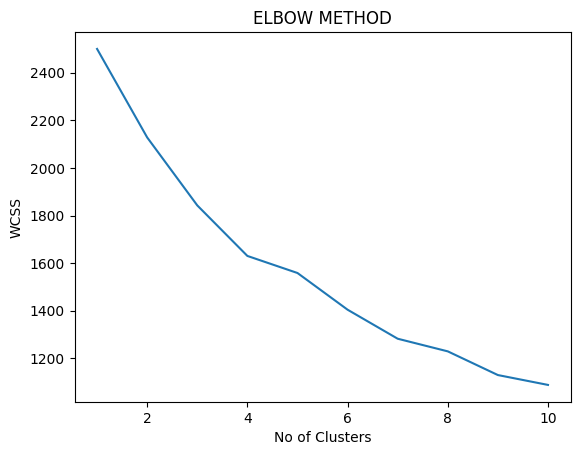

In [26]:
plt.plot(range(1,11),wcss)
plt.title('ELBOW METHOD')
plt.xlabel('No of Clusters')
plt.ylabel('WCSS')
plt.show()

### Task:

1. Silhoutee Score
2. calinski harabasz score
3. IRIS Dataset - apply this clustering techniques and check

# THE END!